11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.9490 - loss: 0.1707 - val_accuracy: 0.9873 - val_loss: 0.0516
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.9851 - loss: 0.0492 - val_accuracy: 0.9880 - val_loss: 0.0454
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9889 - loss: 0.0347 - val_accuracy: 0.9887 - val_loss: 0.0383
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.9924 - loss: 0.0250 - val_accuracy: 0.9905 - val_loss: 0.0312
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9940 - loss: 0.0181 - val_accuracy: 0.9888 - val_loss: 0.0380
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9903 - loss: 0.0274

Test Accuracy: 99.03%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


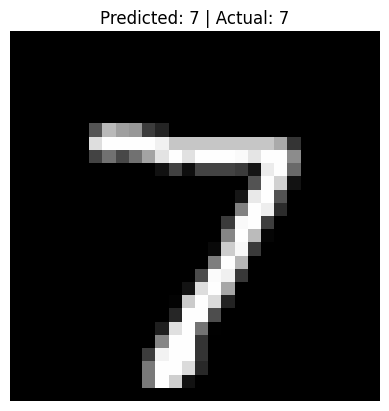

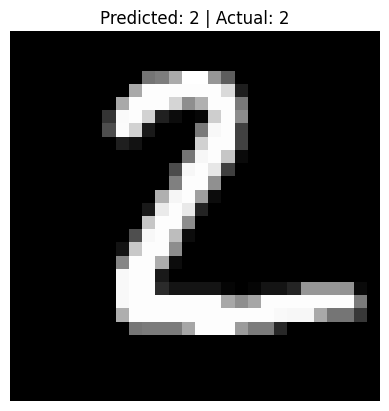

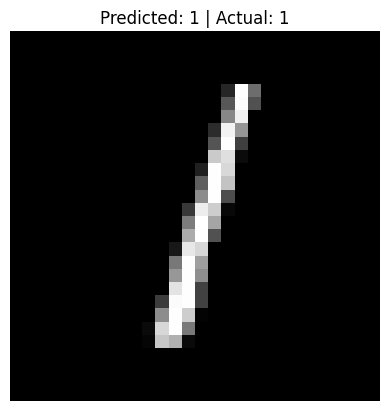

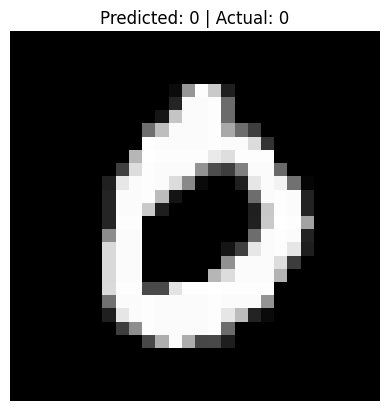

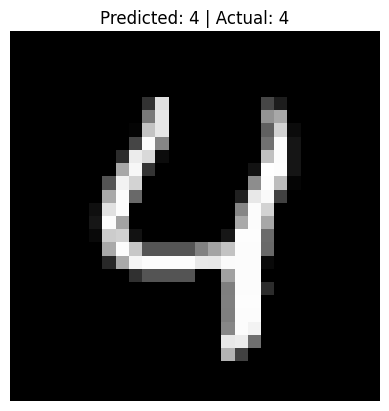

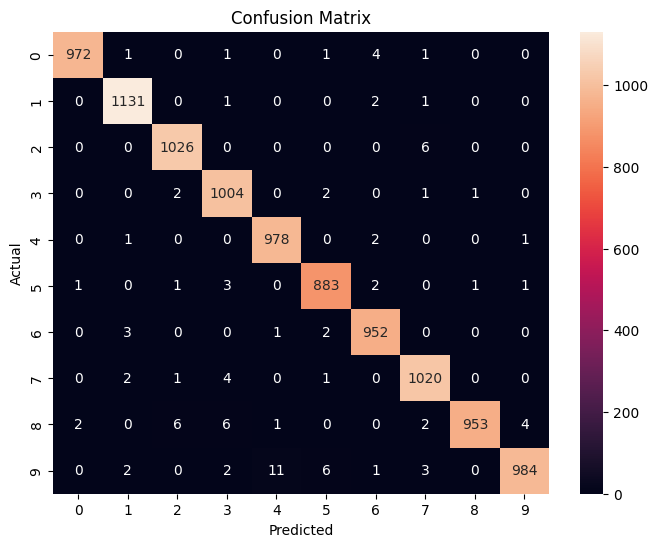

In [2]:



import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1. DATA LOADING
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# -------------------------------
# 2. DATA PREPROCESSING
# -------------------------------
# Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# -------------------------------
# 3. MODEL BUILDING (CNN)
# -------------------------------
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# -------------------------------
# 4. COMPILE MODEL
# -------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 5. TRAIN MODEL
# -------------------------------
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

# -------------------------------
# 6. EVALUATE MODEL
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# -------------------------------
# 7. PREDICTION + INTERPRETATION
# -------------------------------
predictions = model.predict(x_test)

# Show some predictions
for i in range(5):
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])} | Actual: {y_test[i]}")
    plt.axis('off')
    plt.show()

# -------------------------------
# 8. CONFUSION CHECK (OPTIONAL)
# -------------------------------
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()